# My first model

## Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

I0000 00:00:1785947515.626090   43122 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785947515.659472   43122 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%matplotlib widget
plt.close('all')

## Generate Data

In [3]:
f = lambda x,m,q : m*x+q

def generate_data(m, q, sigma, n_points):
    x = np.linspace(0, n_points, n_points)  
    
    y = f(x, m, q)
    
    epsilon = np.random.normal(0, sigma, n_points)
    
    return x, y + epsilon

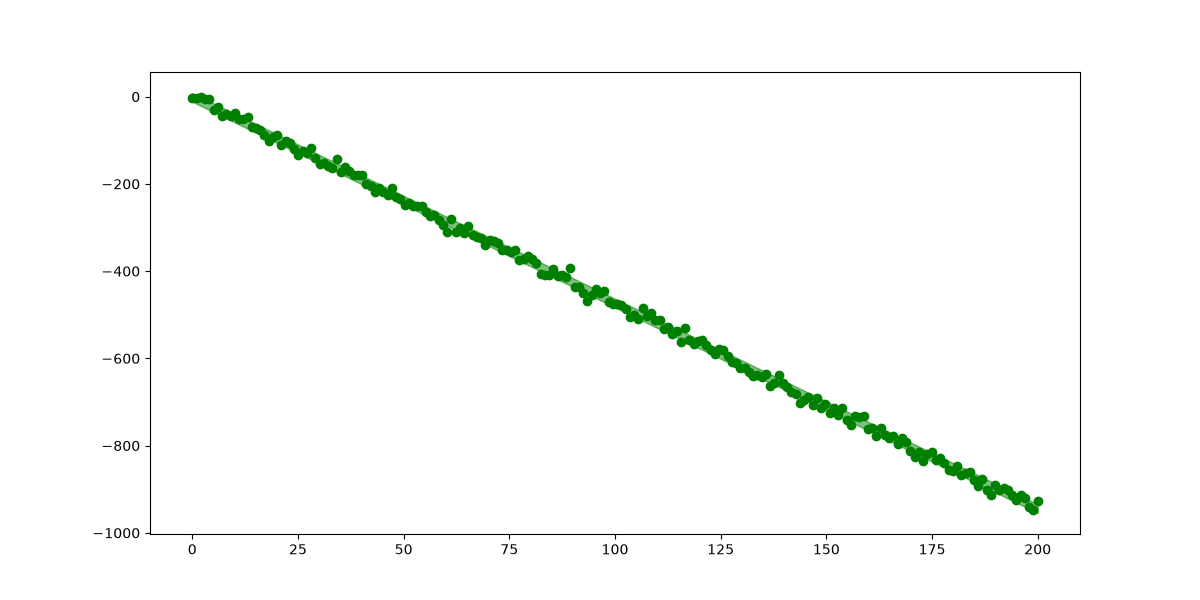

In [4]:

m = (np.random.rand()*10)-5
q = (np.random.rand()*4)-2
sigma = 10

n_points = 200

xs, ys = generate_data(m, q, sigma, n_points)

plt.figure(figsize=(12,6))
plt.scatter(xs,ys,color = "green", marker="o",label = "Generated Data")
plt.fill_between(xs, f(xs, m, q)-sigma, f(xs, m, q)+sigma, color="green", alpha = 0.5)
plt.show()

## Model Definition

In [ ]:
class LinearModel(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        
        self.m = tf.Variable(np.random.randn(), name='m')
        self.q = tf.Variable(np.random.randn(), name='q')

    def __call__(self, x):
        return self.m * x + self.q
    
    def loss(self, y_pred, y_true):
        return tf.reduce_mean(tf.square(y_pred - y_true))
    
    def train_step(self, x, y, learning_rate=0.01):
        with tf.GradientTape() as tape:
            y_pred = self(x)
            current_loss = self.loss(y_pred, y)
            
        gradients = tape.gradient(current_loss, [self.m, self.q])
        self.m.assign_sub(learning_rate * gradients[0])
        self.q.assign_sub(learning_rate * gradients[1])
        return current_loss
    
    def train_loop(self, x, y, epochs=1000, learning_rate=0.01):
        m_values = []
        q_values = []
        loss_values = []
        
        for epoch in range(epochs):
            current_loss = self.train_step(x, y, learning_rate)
            
            if epoch % 10 == 0:
                print(f'Epoch {epoch}: Loss: {current_loss.numpy()}')
                
            m_values.append(self.m.numpy())
            q_values.append(self.q.numpy())
            loss_values.append(current_loss.numpy())
    
        return m_values, q_values, loss_values
    

## Training

In [10]:
my_model = LinearModel()

m_values, q_values, loss_values = my_model.train_loop(xs, ys, epochs=1000, learning_rate=1e-6)

Epoch 0: Loss: 297649.46875
Epoch 10: Loss: 173150.1875
Epoch 20: Loss: 100742.0234375
Epoch 30: Loss: 58629.8046875
Epoch 40: Loss: 34137.546875
Epoch 50: Loss: 19892.97265625
Epoch 60: Loss: 11608.396484375
Epoch 70: Loss: 6790.12353515625
Epoch 80: Loss: 3987.84716796875
Epoch 90: Loss: 2358.058837890625
Epoch 100: Loss: 1410.1781005859375
Epoch 110: Loss: 858.8973999023438
Epoch 120: Loss: 538.2766723632812
Epoch 130: Loss: 351.8038330078125
Epoch 140: Loss: 243.35360717773438
Epoch 150: Loss: 180.27969360351562
Epoch 160: Loss: 143.59576416015625
Epoch 170: Loss: 122.26099395751953
Epoch 180: Loss: 109.85148620605469
Epoch 190: Loss: 102.63427734375
Epoch 200: Loss: 98.43743133544922
Epoch 210: Loss: 95.9962387084961
Epoch 220: Loss: 94.57662200927734
Epoch 230: Loss: 93.7509536743164
Epoch 240: Loss: 93.27062225341797
Epoch 250: Loss: 92.99132537841797
Epoch 260: Loss: 92.82888793945312
Epoch 270: Loss: 92.7343978881836
Epoch 280: Loss: 92.67947387695312
Epoch 290: Loss: 92.64752

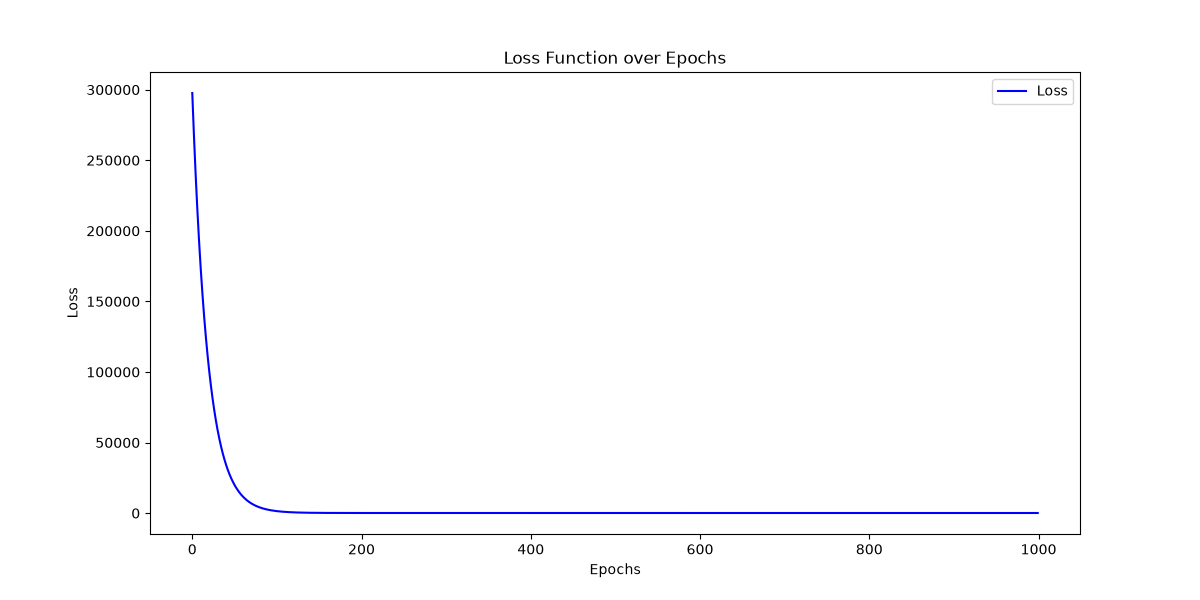

In [11]:
#plot della loss function
plt.figure(figsize=(12,6))
plt.plot(loss_values, label='Loss', color='blue')
plt.title('Loss Function over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

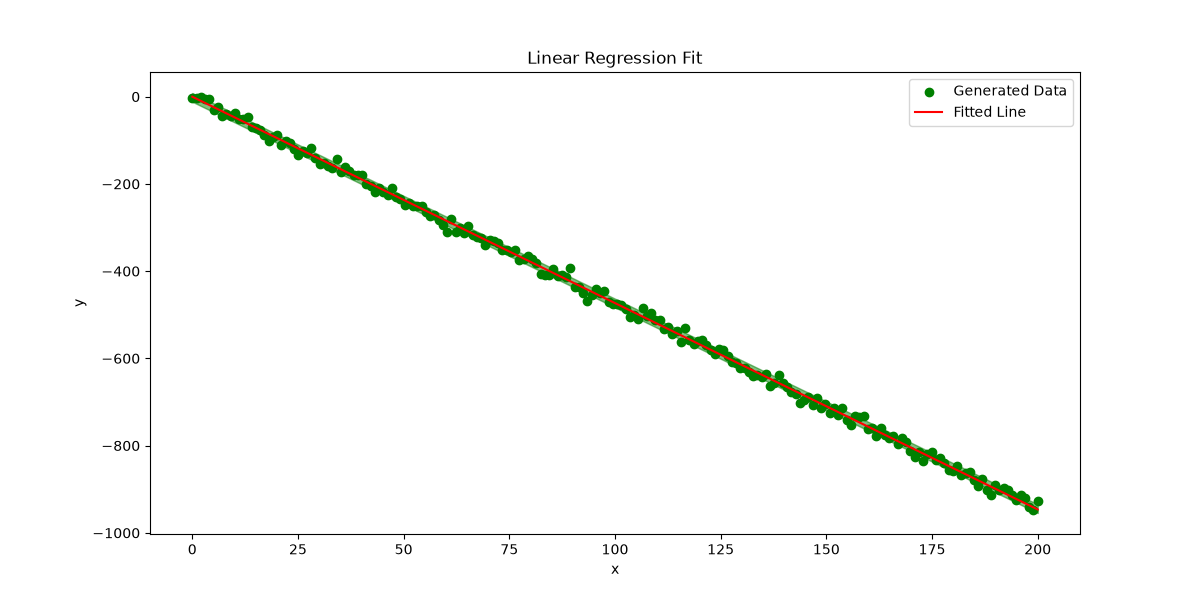

In [12]:
# Plotting the results
plt.figure(figsize=(12,6))
plt.scatter(xs, ys, color='green', marker='o', label='Generated Data')
# Plot the fitted line
plt.plot(xs, my_model(xs), color='red', label='Fitted Line')
plt.fill_between(xs, f(xs, m, q)-sigma, f(xs, m, q)+sigma, color="green", alpha = 0.5)
plt.title('Linear Regression Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()